# Level-Pegging — a quantitative teardown 🔬
### Real total-return tapes · HAC inference · alpha-vs-beta · a block-bootstrapped regime split

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Always wins?: Busted](https://img.shields.io/badge/Always_wins%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We separate the two things equal-weighting does — **tilt to a factor** (a beta you can buy) and **earn an alpha** (what the marketing sells) — and show the alpha is zero over the full sample and only the tilt's *direction* pays, and only in the right regime.

> ⚠️ **Not investment advice.** RSP (equal-weight) & SPY (cap-weight) daily, total-return adjusted (`quantlab.data`, Yahoo); RSP-bounded window from 2003; fees 20 vs 9 bps/yr; 0% cash (nets out of the difference). Sources in [`docs/references.md`](../docs/references.md), reproducible run in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (level_pegging/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from level_pegging import data, strategy

AS_OF = "2026-06-12"
EW_FEE, CW_FEE, SPLIT = 20.0, 9.0, "2015-01-01"
frame = data.load_real("RSP", "SPY", mode="total_return").loc[:AS_OF]
net = strategy.race(frame, EW_FEE, CW_FEE)
ew, cw = net["ew"], net["cw"]
print(f"RSP (EW) + SPY (CW) total return: {len(frame):,} rows  {frame.index[0].date()} -> {frame.index[-1].date()}  fingerprint={data.fingerprint(frame)}")
print(f"EW  Sharpe {ew['sharpe']:.3f}  maxDD {ew['max_dd']*100:.1f}%  CAGR {ew['cagr']*100:.2f}%")
print(f"CW  Sharpe {cw['sharpe']:.3f}  maxDD {cw['max_dd']*100:.1f}%  CAGR {cw['cagr']*100:.2f}%")


RSP (EW) + SPY (CW) total return: 5,817 rows  2003-05-01 -> 2026-06-12  fingerprint=8a1c86dd2b09
EW  Sharpe 0.630  maxDD -60.1%  CAGR 11.07%
CW  Sharpe 0.675  maxDD -55.2%  CAGR 11.39%


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | `MIXED` | Regime-split: EW−CW **+2.60%/yr** (HAC *t* +1.97) in 2003-2015, **-2.74%/yr** (HAC *t* -1.57) in 2015-2026; difference-of-differences **5.34 pts/yr**, block-boot *p* = **0.019**. Full-sample alpha **-0.23%/yr** (HAC *t* -0.21). |
| **Tradability** | `MIRAGE` | As *"just buy RSP and always win"*: EW−CW = **-0.32 pts/yr** net over the full sample; the tilt is β≈1.02 to the cap-weight market, not skill. |
| **Always wins?** | `BUSTED` | RSP/SPY relative wealth peaked **1.305** (2011-05-20) then fell to **0.936**. |

> 💡 **In plain words:** equal-weighting is a *factor tilt wearing a free-lunch costume*; the tilt's payoff flips sign with the market's breadth.

## 1 · The claim, steelmanned

- **H₁ (tilt):** EW is a mechanical small-cap / anti-concentration tilt — it should have β≈1 to the cap-weight market plus a size loading.
- **H₂ (alpha):** beyond the tilt, the *rebalancing* earns a positive alpha (Plyakha, Uppal & Vilkov).
- **H₃ (the sold claim):** EW therefore **always** beats CW.

We find H₁ true, H₂ ≈ 0 over the full investable sample, and H₃ false — the edge **flips sign** across a justified regime split.

## 2 · So what? — what rides on each answer

If H₃ held, cap-weighted indexing — the default for trillions — would be dominated by a re-weighting of the *same names*. It isn't; seeing *why* (a breadth bet, not alpha) is the lesson.

## 3 · How we'd know — the protocol

Full-sample race (net of fees) · HAC inference on the daily EW−CW difference · block-bootstrap CI on the mean difference · alpha-vs-beta regression of EW on CW · a **regime split** at 2015-01-01 with a block-bootstrap test of the difference-of-differences (a justified, not snooped, split).

## 4 · The teardown

Headline stats, full sample, net of each arm's fee:

In [2]:
tbl = pd.DataFrame({
  'CAGR %':  [ew['cagr']*100, cw['cagr']*100],
  'Vol %':   [ew['vol']*100, cw['vol']*100],
  'Sharpe':  [ew['sharpe'], cw['sharpe']],
  'MaxDD %': [ew['max_dd']*100, cw['max_dd']*100],
  'Final x': [ew['final'], cw['final']],
}, index=['RSP equal-weight', 'SPY cap-weight'])
tbl.round(3)

,CAGR %,Vol %,Sharpe,MaxDD %,Final x
RSP equal-weight,11.070,19.799,0.630,-60.054,11.286
SPY cap-weight,11.388,18.540,0.675,-55.246,12.055


**HAC inference** on the daily EW−CW return difference, plus a block-bootstrap CI on its mean:

In [3]:
diff = net['diff'].to_numpy()
t = strategy.hac_tstat(diff)
lo, hi = strategy.block_bootstrap_mean_ci(diff)
print(f'mean daily EW-CW = {diff.mean()*1e4:+.3f} bps/day   HAC t = {t:+.2f}')
print(f'block-boot 95% CI on the mean = [{lo*1e4:+.3f}, {hi*1e4:+.3f}] bps/day (straddles 0)')
print('=> over the full RSP era the difference is statistically indistinguishable from zero.')

mean daily EW-CW = -0.016 bps/day   HAC t = -0.04
block-boot 95% CI on the mean = [-0.895, +0.853] bps/day (straddles 0)
=> over the full RSP era the difference is statistically indistinguishable from zero.


> 💡 **In plain words:** day to day, equal-weight and cap-weight are the same bet plus noise; the full-sample winner is decided by *which regime ran longer*, not by a steady edge.

**Alpha vs beta** — regress EW's daily return on CW's. Beta is the market exposure; the intercept is what's left:

In [4]:
ab = strategy.alpha_beta(frame)
print(f"alpha = {ab['alpha_ann']*100:+.2f}%/yr (HAC t {ab['t_alpha']:+.2f})")
print(f"beta  = {ab['beta']:.3f}   R^2 = {ab['r2']:.3f}")
print('=> EW is ~the cap-weight market (beta ~1, R^2 ~0.92) with NO certifiable alpha over the full sample.')

alpha = -0.23%/yr (HAC t -0.21)
beta  = 1.024   R^2 = 0.919
=> EW is ~the cap-weight market (beta ~1, R^2 ~0.92) with NO certifiable alpha over the full sample.


> 💡 **In plain words:** strip out the part of RSP that's just *the market*, and there's nothing reliable left over — the 'rebalancing premium' is not visible in the investable fund's full history.

**The regime split** — the heart of it. Cut at 2015, race each half, and test whether the two halves' EW−CW means really differ (block bootstrap on the difference-of-differences):

In [5]:
sc = strategy.split_contrast(net['diff'], SPLIT)
early = frame.loc[:SPLIT]; late = frame.loc[SPLIT:]
re_, rl = strategy.race(early, EW_FEE, CW_FEE), strategy.race(late, EW_FEE, CW_FEE)
print(f"early 2003-2015 : EW-CW {sc['early_ann']*100:+.2f}%/yr (HAC t {sc['early_t']:+.2f})  "
      f"Sharpe EW {re_['ew']['sharpe']:.3f} vs CW {re_['cw']['sharpe']:.3f}")
print(f"late  2015-2026 : EW-CW {sc['late_ann']*100:+.2f}%/yr (HAC t {sc['late_t']:+.2f})  "
      f"Sharpe EW {rl['ew']['sharpe']:.3f} vs CW {rl['cw']['sharpe']:.3f}")
print(f"difference-of-differences = {sc['obs_gap_ann']*100:+.2f} pts/yr   block-boot p = {sc['p_boot']:.4f}")

early 2003-2015 : EW-CW +2.60%/yr (HAC t +1.97)  Sharpe EW 0.622 vs CW 0.552
late  2015-2026 : EW-CW -2.74%/yr (HAC t -1.57)  Sharpe EW 0.644 vs CW 0.814
difference-of-differences = +5.34 pts/yr   block-boot p = 0.0188


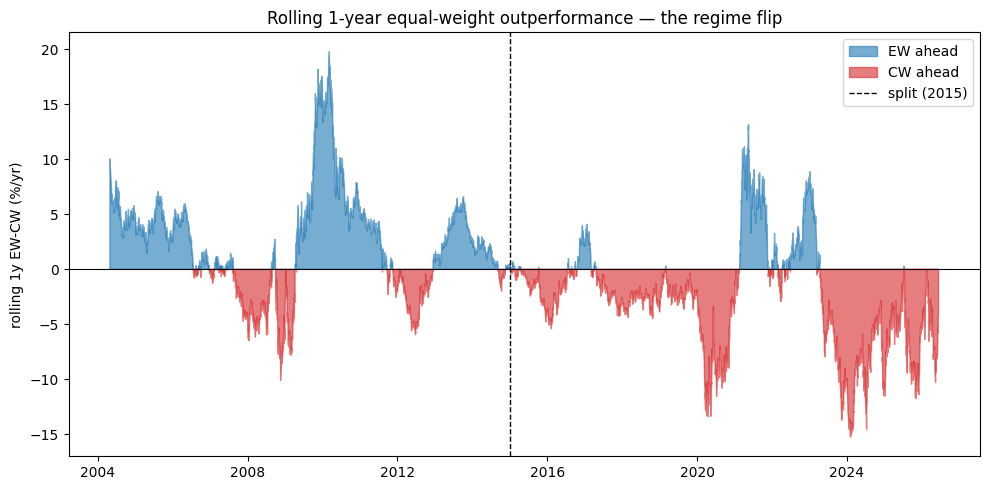

In [6]:
# Rolling 1-year EW-CW outperformance: the regime flip made visible.
roll = net['diff'].rolling(252).mean() * 252 * 100
fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(roll.index, 0, roll, where=roll>=0, color='C0', alpha=.6, label='EW ahead')
ax.fill_between(roll.index, 0, roll, where=roll<0, color='C3', alpha=.6, label='CW ahead')
ax.axhline(0, color='k', lw=.8)
ax.axvline(pd.Timestamp(SPLIT), color='k', lw=1.0, ls='--', label='split (2015)')
ax.set_ylabel('rolling 1y EW-CW (%/yr)'); ax.set_title('Rolling 1-year equal-weight outperformance — the regime flip')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 **In plain words:** the blue (EW-ahead) years cluster early; the red (CW-ahead) years cluster after 2015. The block-bootstrap *p* on the gap says that clustering is unlikely to be luck — the regimes are real, which is exactly why *"always"* is the wrong word.

## 5 · The verdict

Signal `MIXED` (early EW−CW +2.60%/yr at *t* +1.97; late -2.74%/yr; difference-of-differences 5.34 pts/yr at *p* 0.019; full-sample alpha -0.23%/yr, *t* -0.21). Tradability `MIRAGE` for *"just buy RSP and always win"* (EW−CW -0.32 pts/yr net, β≈1.02). Always wins? `BUSTED` (relative wealth 1.305 → 0.936).

## 6 · Could you trade it?

Capacity is a non-issue (RSP and SPY are deep). The binding fact is economic: equal-weight is a **conditional bet on breadth**, β≈1 to the cap-weight market, with no full-sample alpha and a higher fee/turnover drag. To make *"always"* true you would have to **time the regime** — hold EW when leadership broadens, CW when it narrows — which is a different, harder strategy than the buy-and-hold the claim sells.

## 7 · Going further

- Decompose the early-era EW win into **Fama-French SMB/HML** loadings — how much is just small-cap value?
- Build a **top-10-weight (concentration) signal** and test whether it times the EW vs CW switch out of sample.
- Re-run on **equal- vs cap-weight outside the US** (less mega-cap concentration) — does the tilt earn its fee there?